# nanochst: Supervised Fine-Tuning 
## Yoav Ram

This notebook continues from `nanochat.ipynb`.
We take the *pretrained* language model and teach it to follow instructions via *supervised fine-tuning* or **SFT**.

Prerequisite: run `nanochat.ipynb` first — it saves `checkpoints/nanochat_checkpoint.pkl`.

In [4]:
# ── All model definitions (identical to nanochat.ipynb) ──────────────────
import os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pickle
import math
import re
import urllib.request
import optax
from functools import partial

from bpe import bpe_encode, bpe_decode, bpe_load

/Users/yoavram/Work/Teaching/nanochat/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# ── Model ─────────────────────────────────────────────────────────────────
def rms_norm(g, x, eps=1e-6):
    return g * x / jnp.sqrt(jnp.mean(x**2, axis=-1, keepdims=True) + eps)

def precompute_rope(seq_len, head_dim, base=10000.):
    i = jnp.arange(0, head_dim, 2)
    angles = jnp.outer(jnp.arange(seq_len), 1.0 / (base ** (i / head_dim)))
    angles = jnp.concatenate([angles, angles], axis=-1)
    return jnp.cos(angles), jnp.sin(angles)

def apply_rope(x, cos, sin):
    d = x.shape[-1] // 2
    return x * cos + jnp.concatenate([-x[..., d:], x[..., :d]], axis=-1) * sin

def causal_mask(T):
    return jnp.where(jnp.tril(jnp.ones((T, T))), 0., -jnp.inf)

def attention_forward(p, x, cos, sin, mask):
    B, T, d = x.shape; hd = cos.shape[-1]; H = d // hd
    Q, K, V = x @ p['Wq'], x @ p['Wk'], x @ p['Wv']
    def sh(t): return t.reshape(B, T, H, hd).transpose(0, 2, 1, 3)
    Q, K, V = sh(Q), sh(K), sh(V)
    c, s = cos[None, None], sin[None, None]
    Q = apply_rope(Q, c, s) / (jnp.linalg.norm(Q, axis=-1, keepdims=True) + 1e-6)
    K = apply_rope(K, c, s) / (jnp.linalg.norm(K, axis=-1, keepdims=True) + 1e-6)
    w = jax.nn.softmax(Q @ K.transpose(0, 1, 3, 2) / math.sqrt(hd) + mask[None, None], axis=-1)
    return (w @ V).transpose(0, 2, 1, 3).reshape(B, T, d) @ p['Wo'], w

def mlp_forward(p, x):
    return jax.nn.relu(x @ p['W1']) ** 2 @ p['W2']

def forward(params, ids, cos, sin, mask):
    x = params['tok_emb']['W'][ids]
    for blk in params['blocks']:
        x = x + attention_forward(blk['attn'], rms_norm(blk['norm1']['g'], x), cos, sin, mask)[0]
        x = x + mlp_forward(blk['mlp'], rms_norm(blk['norm2']['g'], x))
    return rms_norm(params['norm_f']['g'], x) @ params['head']['W'].T

def sample_token(key, logits, temperature=1.0, top_k=0, top_p=1.0):
    logits = logits / temperature
    if top_k > 0:
        kth = jnp.sort(logits)[-top_k]
        logits = jnp.where(logits < kth, -jnp.inf, logits)
    probs = jax.nn.softmax(logits)
    if top_p < 1.0:
        sorted_idx = jnp.argsort(-probs)
        cumsum     = jnp.cumsum(probs[sorted_idx])
        keep  = jnp.concatenate([jnp.array([True]), cumsum[:-1] <= top_p])
        mask  = jnp.zeros_like(probs).at[sorted_idx].set(keep.astype(probs.dtype))
        probs = probs * mask
        probs = probs / (probs.sum() + 1e-9)
    return jax.random.choice(key, probs.shape[0], p=probs)

def generate(params, vocab, merges, prompt, cfg,
             max_new_tokens=80, temperature=1.0, top_k=0, top_p=1.0, key=None):
    if key is None: key = jax.random.PRNGKey(0)
    seq_len = cfg.get('seq_len', 128)
    ids = bpe_encode(prompt, vocab, merges)
    for _ in range(max_new_tokens):
        ctx = ids[-seq_len:]; T = len(ctx)
        cos, sin = precompute_rope(T, cfg['head_dim'])
        logits = forward(params, jnp.array([ctx]), cos, sin, causal_mask(T))[0, -1]
        key, sub = jax.random.split(key)
        ids.append(int(sample_token(sub, logits, temperature, top_k, top_p)))
    return bpe_decode(ids, vocab)

def save_checkpoint(params, cfg, vocab, merges, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'wb') as f:
        pickle.dump({'params': jax.tree_util.tree_map(np.array, params),
                     'cfg': cfg, 'vocab': vocab, 'merges': merges}, f)
    print(f'Saved -> {path}')

def load_checkpoint(path):
    with open(path, 'rb') as f: s = pickle.load(f)
    vocab  = s['vocab']
    merges = [tuple(m) for m in s['merges']]
    return jax.tree_util.tree_map(jnp.array, s['params']), s['cfg'], vocab, merges

print(f'JAX {jax.__version__} | {jax.default_backend()}')

JAX 0.9.2 | cpu


In [6]:
CHECKPOINT = 'checkpoints/nanochat_checkpoint.pkl'

pretrained_params, cfg, vocab, merges = load_checkpoint(CHECKPOINT)

context_len  = cfg.get('seq_len', 128)
cos_c, sin_c = precompute_rope(context_len, cfg['head_dim'])
mask_c       = causal_mask(context_len)

print(f'Loaded model: {cfg}')
print(f'Vocab size:   {len(vocab)}')

print('\nPretrained sample (no instruction):')
print(generate(pretrained_params, vocab, merges, 'Once upon a time', cfg,
               max_new_tokens=40, temperature=0.8, key=jax.random.PRNGKey(1)))

Loaded model: {'vocab_size': 1024, 'd_model': 512, 'n_heads': 8, 'n_layers': 8, 'd_ff': 2048, 'head_dim': 64, 'seq_len': 256}
Vocab size:   1024

Pretrained sample (no instruction):
Once upon a time there was a little girl called Lily. She was three years old and curious every day. One 


## What is Supervised Fine-Tuning - SFT?

After pretraining, the model can complete text — it predicts the next token.
It has no concept of a "question" or "instruction". 
Given the prompt `Write a story about a dog.` it might output more instructions rather than a story.

SFT teaches the model a **format**: given a prompt, produce a specific type of response.
This is done by training on `(prompt, response)` pairs, masking the loss on the prompt
so the model only learns to predict the response.

```
Pretraining batch:
  tokens:  [t₁  t₂  t₃  t₄  t₅  t₆  t₇  t₈]
  loss on:  [✓   ✓   ✓   ✓   ✓   ✓   ✓   ✓ ]

SFT batch:
  tokens:  [PROMPT TOKENS  |  RESPONSE TOKENS      ]
  loss on:  [✗   ✗   ✗   ✗  |  ✓    ✓    ✓    ✓   ]
```

The cross-entropy loss is identical to that of pre-training — we just zero-out the prompt positions:

$$\text{NLL}_{\text{SFT}} = -\frac{1}{R} \sum_{t=P+1}^{R} \log p(x_t \mid x_{<t})$$

where tokens $1,\ldots,P$ are the prompt and tokens $P+1,\ldots,R$ are the response.

Why mask the prompt?
If we included the prompt in the loss, the model would learn the instruction format (which is fixed) rather than learning to produce good responses to specific prompts.

## SFT Dataset

We build `(prompt, response)` pairs directly from TinyStories:

- **Prompt**: `Continue the story: {first sentence}`
- **Response**: `{remainder of the story}`

This requires no new data and gives a clear demonstration:
before SFT, the model ignores the instruction prefix;
after SFT, it reliably produces a story continuation.

In [7]:
CACHE = "data/TinyStoriesV2-GPT4-valid.txt"
with open(CACHE, encoding='utf-8') as f:
    raw = f.read()
    
MAX_STORIES = 100_000
stories = [s.strip() for s in raw.split('<|endoftext|>') if s.strip()][:MAX_STORIES]
text    = "\n".join(stories)
print(f"Stories: {len(stories):,}  |  Characters: {len(text):,}")

Stories: 27,630  |  Characters: 22,095,533


### Chat template

We use a minimal template with explicit role markers:

```
[INST] Continue the story: {first sentence} [/INST] {rest of story}
```

The tokens `[INST]` and `[/INST]` are not special tokens in our BPE vocab —
they will be tokenised as subword pieces. That's fine for this demonstration.
In production models, special tokens are added to the vocabulary and always
tokenised as a single unit (like GPT-2's `<|endoftext|>`).

In [8]:
def make_sft_example(story, vocab, merges, seq_len):
    """
    Split story into prompt (first sentence) + response (rest).
    Returns (input_ids, target_ids, response_mask) or None if story is too short.
    """
    dot = story.find('. ')
    if dot == -1 or dot > len(story) * 0.7:
        return None

    first_sent = story[:dot + 2]
    rest       = story[dot + 2:]
    if len(rest) < 20:
        return None

    prompt   = f'[INST] Continue the story: {first_sent}[/INST] '
    response = rest

    p_ids = bpe_encode(prompt, vocab, merges)
    r_ids = bpe_encode(response, vocab, merges)

    combined = (p_ids + r_ids)[:seq_len + 1]
    if len(combined) < seq_len + 1:
        return None

    inputs  = np.array(combined[:seq_len], dtype=np.int32)
    targets = np.array(combined[1:seq_len + 1], dtype=np.int32)

    resp_start = min(len(p_ids), seq_len)
    mask = np.zeros(seq_len, dtype=np.float32)
    mask[resp_start:] = 1.0

    return inputs, targets, mask

In [9]:
sft_examples = []
for story in stories:
    ex = make_sft_example(story, vocab, merges, context_len)
    if ex is not None:
        sft_examples.append(ex)

print(f'SFT examples created: {len(sft_examples):,}')

split_idx = max(1, int(0.9 * len(sft_examples)))
split_idx = min(split_idx, len(sft_examples) - 1)
train_examples = sft_examples[:split_idx]
val_examples   = sft_examples[split_idx:]
print(f'Train examples: {len(train_examples):,}')
print(f'Validation examples: {len(val_examples):,}')

inputs, targets, resp_mask = sft_examples[0]
resp_start = int(resp_mask.argmax())
print(f'\nExample:')
print(f'  Prompt  (inputs[:{resp_start}]):           {bpe_decode(inputs[:resp_start].tolist(), vocab)!r}')
print(f'  Response (targets[{resp_start}:{resp_start+30}]): {bpe_decode(targets[resp_start:resp_start+30].tolist(), vocab)!r}')
print(f'  Mask:   {resp_mask[:resp_start+5]}')
print(f'  Response starts at position: {resp_start}')


SFT examples created: 26,805
Train examples: 24,124
Validation examples: 2,681

Example:
  Prompt  (inputs[:60]):           '[INST] Continue the story: Once upon a time, in a warm and sunny place, there was a big pit. [/INST] '
  Response (targets[60:90]): ' little boy named Tom liked to play near the pit. One day, Tom lost'
  Mask:   [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
  Response starts at position: 60


## 3. SFT Loss

The only code change from pretraining: multiply the per-token loss by `response_mask`
and normalise by the number of response tokens (not total tokens).

```python
# Pretraining loss:
loss = -mean(log_probs[correct_token])            # over ALL positions

# SFT loss:
loss = -sum(log_probs[correct_token] * mask) / sum(mask)      # only RESPONSE positions
```

The gradient flows only through the response positions —
the prompt positions have zero loss and contribute nothing to the parameter update.

In [7]:
def sft_loss_fn(params, inputs, targets, response_mask):
    """
    inputs         : (B, T) int
    targets        : (B, T) int   — next-token targets
    response_mask  : (B, T) float — 1.0 at response positions, 0.0 at prompt
    """
    B, T = inputs.shape
    logits   = forward(params, inputs, cos_c[:T], sin_c[:T], mask_c[:T, :T])
    log_probs = jax.nn.log_softmax(logits, axis=-1)           # (B, T, V)
    # Log-prob of the actual next token at each position
    correct   = log_probs[jnp.arange(B)[:, None],
                          jnp.arange(T)[None, :],
                          targets]                             # (B, T)
    # Masked mean: loss only on response tokens
    loss = -(correct * response_mask).sum() / (response_mask.sum() + 1e-8)
    return loss

lr        = 3e-5
optimizer = optax.adamw(lr, weight_decay=0.1)

@jax.jit
def sft_train_step(params, opt_state, inputs, targets, response_mask):
    def loss_fn(p):
        return sft_loss_fn(p, inputs, targets, response_mask)
    loss, grads = jax.value_and_grad(loss_fn, allow_int=True)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@jax.jit
def sft_eval_step(params, inputs, targets, response_mask):
    return sft_loss_fn(params, inputs, targets, response_mask)


# Verify: loss is lower for the correct response than for a random one
inputs_ex = jnp.array([sft_examples[0][0]])
targets_ex = jnp.array([sft_examples[0][1]])
mask_ex    = jnp.array([sft_examples[0][2]])
print(f'SFT loss (pretrained model): {float(sft_loss_fn(pretrained_params, inputs_ex, targets_ex, mask_ex)):.4f}')

SFT loss (pretrained model): 0.9850


## 4. SFT Training

The training loop is identical to pretraining with two changes:
1. Batches come from the SFT dataset (prompt+response pairs)
2. We pass `response_mask` to the loss function

We use a lower learning rate (3e-5 rather than 3e-4) to avoid catastrophic forgetting: we want to refine the model's behaviour, not overwrite its world knowledge.

In [8]:
batch_size           = 8
n_steps              = 200
log_every            = 20
checkpoint_every     = 50
patience             = 4
min_delta            = 1e-3
checkpoint_path      = 'checkpoints/nanochat_sft_checkpoint.pkl'
best_checkpoint_path = 'checkpoints/nanochat_sft_best.pkl'

# Start SFT from the pretrained weights
params_sft = pretrained_params
opt_state  = optimizer.init(params_sft)

key = jax.random.PRNGKey(0)
sft_losses, steps_log = [], []
best_val             = float('inf')
best_step            = 0
checks_since_best    = 0

print(f'SFT training: {n_steps} steps, batch={batch_size}, lr={lr}')
print(f'{"Step":>6}  {"Train":>10}  {"Val":>10}  {"Best":>10}')
print('-' * 46)

for step in range(1, n_steps + 1):
    key, subkey = jax.random.split(key)
    idx    = jax.random.randint(subkey, (batch_size,), 0, len(train_examples))
    batch  = [train_examples[int(i)] for i in idx]
    inputs = jnp.array([b[0] for b in batch])
    targets= jnp.array([b[1] for b in batch])
    masks  = jnp.array([b[2] for b in batch])

    params_sft, opt_state, loss = sft_train_step(params_sft, opt_state, inputs, targets, masks)

    if step % checkpoint_every == 0:
        save_checkpoint(params_sft, cfg, vocab, merges, checkpoint_path)
        print(f'checkpoint step {step:>6} -> {checkpoint_path}')

    if step % log_every == 0 or step == n_steps:
        key, subkey = jax.random.split(key)
        idx_v   = jax.random.randint(subkey, (batch_size,), 0, len(val_examples))
        batch_v = [val_examples[int(i)] for i in idx_v]
        inputs_v  = jnp.array([b[0] for b in batch_v])
        targets_v = jnp.array([b[1] for b in batch_v])
        masks_v   = jnp.array([b[2] for b in batch_v])
        val_loss = float(sft_eval_step(params_sft, inputs_v, targets_v, masks_v))

        sft_losses.append(float(loss))
        steps_log.append(step)

        if val_loss < best_val - min_delta:
            best_val = val_loss
            best_step = step
            checks_since_best = 0
            save_checkpoint(params_sft, cfg, vocab, merges, best_checkpoint_path)
            print(f'best checkpoint step {step:>6} -> {best_checkpoint_path}')
        else:
            checks_since_best += 1

        print(f'{step:>6}  {float(loss):>10.4f}  {val_loss:>10.4f}  {best_val:>10.4f}')

        if checks_since_best >= patience:
            print(f'Early stopping at step {step} (best step {best_step}, best val {best_val:.4f})')
            break

print('Done.')

SFT training: 200 steps, batch=8, lr=3e-05
  Step       Train         Val        Best
----------------------------------------------


E0410 16:57:21.651685 3422829 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.226 = f32[1536,512]{0,1} fusion(bitcast.2195, bitcast.134, bitcast.135, bitcast.136), kind=kCustom, calls=gemm_fusion_dot.226_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 16:57:21.651872 3422829 xtile_compiler.cc:401] Computation: gemm_fusion_dot.226_computation.clone {
  parameter_1.127 = f32[2048,512]{1,0} parameter(1)
  parameter_2.8 = f32[2048,512]{1,0} parameter(2)
  parameter_3.8 = f32[2048,512]{1,0} parameter(3)
  concatenate.98 = f32[2048,1536]{1,0} concatenate(parameter_1.127, parameter_2.8, parameter_3.8), dimensions={1}
  bitc

E0410 16:57:22.028411 3422896 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.224 = f32[1536,2048]{0,1} fusion(bitcast.2195, params__blocks___0___attn____Wk__.1, params__blocks___0___attn____Wq__.1, params__blocks___0___attn____Wv__.1), kind=kCustom, calls=gemm_fusion_dot.224_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 16:57:22.028820 3422896 xtile_compiler.cc:401] Computation: gemm_fusion_dot.224_computation.clone {
  parameter_1 = f32[512,512]{1,0} parameter(1)
  parameter_2 = f32[512,512]{1,0} parameter(2)
  parameter_3 = f32[512,512]{1,0} parameter(3)
  concatenate.90 = f32[512,1536]{1,0} concatenate(paramet

E0410 16:57:22.276559 3422839 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.224 = f32[4,1536,2048]{1,2,0} fusion(bitcast.2, params__blocks___0___attn____Wk__.1, params__blocks___0___attn____Wq__.1, params__blocks___0___attn____Wv__.1), kind=kCustom, calls=gemm_fusion_dot.224_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 16:57:22.276941 3422839 xtile_compiler.cc:401] Computation: gemm_fusion_dot.224_computation.clone {
  parameter_1 = f32[512,512]{1,0} parameter(1)
  parameter_2 = f32[512,512]{1,0} parameter(2)
  parameter_3 = f32[512,512]{1,0} parameter(3)
  concatenate.90 = f32[512,1536]{1,0} concatenate(p

E0410 16:57:22.606899 3422827 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.226 = f32[4,1536,512]{1,2,0} fusion(bitcast.2, bitcast.134, bitcast.135, bitcast.136), kind=kCustom, calls=gemm_fusion_dot.226_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 16:57:22.607041 3422827 xtile_compiler.cc:401] Computation: gemm_fusion_dot.226_computation.clone {
  parameter_1.127 = f32[2048,512]{1,0} parameter(1)
  parameter_2.8 = f32[2048,512]{1,0} parameter(2)
  parameter_3.8 = f32[2048,512]{1,0} parameter(3)
  concatenate.98 = f32[2048,1536]{1,0} concatenate(parameter_1.127, parameter_2.8, parameter_3.8), dimensions={1}
 

...

Saved -> checkpoints/nanochat_sft_checkpoint.pkl
checkpoint step    100 -> checkpoints/nanochat_sft_checkpoint.pkl
   100      1.0975      1.1705      0.8701


   120      0.8182      0.9084      0.8701


   140      1.0713      1.0020      0.8701


Saved -> checkpoints/nanochat_sft_checkpoint.pkl
checkpoint step    150 -> checkpoints/nanochat_sft_checkpoint.pkl


   160      0.8802      0.9808      0.8701
Early stopping at step 160 (best step 80, best val 0.8701)
Done.


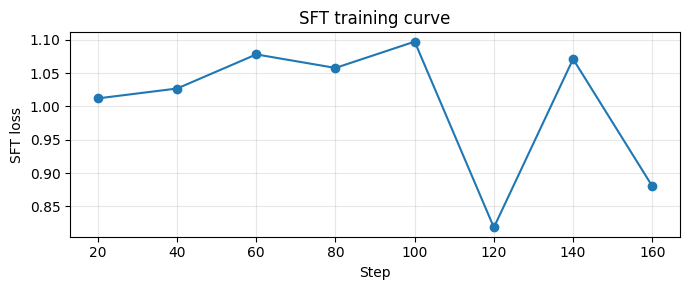

In [9]:
plt.figure(figsize=(7, 3))
plt.plot(steps_log, sft_losses, marker='o')
plt.xlabel('Step'); plt.ylabel('SFT loss'); plt.title('SFT training curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Evaluation: Pretrained vs SFT

We prompt both models with the instruction format and compare their outputs.
The pretrained model was never trained to respond to `[INST]...[/INST]`,
so it will likely ignore the instruction and continue free-form.
The SFT model has learned to produce a story continuation after `[/INST]`.

In [10]:
test_prompts = [
    'Once upon a time there was a little cat named Mia. ',
    'One sunny day, a boy named Tom went to the park. ',
]

for first_sent in test_prompts:
    prompt = f'[INST] Continue the story: {first_sent}[/INST] '
    print(f'Prompt: {first_sent!r}')
    print(f'\nPretrained:')
    print(generate(pretrained_params, vocab, merges, prompt, cfg,
                   max_new_tokens=50, temperature=0.8, key=jax.random.PRNGKey(42)))
    print(f'\nAfter SFT:')
    print(generate(params_sft, vocab, merges, prompt, cfg,
                   max_new_tokens=50, temperature=0.8, key=jax.random.PRNGKey(42)))
    print('\n' + '='*70 + '\n')

Prompt: 'Once upon a time there was a little cat named Mia. '

Pretrained:


E0410 16:57:50.376666 3422904 xtile_compiler.cc:399] Fusion: gemm_fusion_dot = f32[8,50,50]{2,1,0} fusion(bitcast.9, bitcast.8), kind=kCustom, calls=gemm_fusion_dot_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 16:57:50.376763 3422904 xtile_compiler.cc:401] Computation: gemm_fusion_dot_computation.clone {
  parameter_0 = f32[8,50,64]{2,1,0} parameter(0)
  parameter_1 = f32[8,64,50]{2,1,0} parameter(1)
  ROOT dot.1 = f32[8,50,50]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0410 16:57:50.388

E0410 16:57:51.843750 3422910 xtile_compiler.cc:399] Fusion: gemm_fusion_dot = f32[8,64,50]{1,2,0} fusion(bitcast.9, bitcast.10), kind=kCustom, calls=gemm_fusion_dot_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","32","256"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 16:57:51.843835 3422910 xtile_compiler.cc:401] Computation: gemm_fusion_dot_computation.clone {
  parameter_1 = f32[8,50,64]{2,1,0} parameter(1)
  parameter_0 = f32[8,50,50]{2,1,0} parameter(0)
  ROOT dot.2 = f32[8,64,50]{1,2,0} dot(parameter_1, parameter_0), lhs_batch_dims={0}, lhs_contracting_dims={1}, rhs_batch_dims={0}, rhs_contracting_dims={2}, backend_config={"sizes":["32"]}
}
E0410 16:57:51.915

E0410 16:57:57.604922 3422863 xtile_compiler.cc:399] Fusion: gemm_fusion_dot = f32[8,51,51]{2,1,0} fusion(bitcast.9, bitcast.8), kind=kCustom, calls=gemm_fusion_dot_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 16:57:57.605014 3422863 xtile_compiler.cc:401] Computation: gemm_fusion_dot_computation.clone {
  parameter_0 = f32[8,51,64]{2,1,0} parameter(0)
  parameter_1 = f32[8,64,51]{2,1,0} parameter(1)
  ROOT dot.1 = f32[8,51,51]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0410 16:57:57.631

E0410 16:57:59.022202 3422835 xtile_compiler.cc:399] Fusion: gemm_fusion_dot = f32[8,64,51]{1,2,0} fusion(bitcast.9, bitcast.10), kind=kCustom, calls=gemm_fusion_dot_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","32","256"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 16:57:59.022290 3422835 xtile_compiler.cc:401] Computation: gemm_fusion_dot_computation.clone {
  parameter_1 = f32[8,51,64]{2,1,0} parameter(1)
  parameter_0 = f32[8,51,51]{2,1,0} parameter(0)
  ROOT dot.2 = f32[8,64,51]{1,2,0} dot(parameter_1, parameter_0), lhs_batch_dims={0}, lhs_contracting_dims={1}, rhs_batch_dims={0}, rhs_contracting_dims={2}, backend_config={"sizes":["32"]}
}
E0410 16:57:59.046

...

E0410 17:04:20.937497 3422891 xtile_compiler.cc:399] Fusion: gemm_fusion_dot = f32[8,99,64]{2,1,0} fusion(bitcast.9, bitcast.8), kind=kCustom, calls=gemm_fusion_dot_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0410 17:04:20.937581 3422891 xtile_compiler.cc:401] Computation: gemm_fusion_dot_computation.clone {
  parameter_0 = f32[8,99,99]{2,1,0} parameter(0)
  parameter_1 = f32[8,99,64]{2,1,0} parameter(1)
  ROOT dot.1 = f32[8,99,64]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":["64"]}
}
E0410 17:04:20.94007

[INST] Continue the story: Once upon a time there was a little cat named Mia. [/INST] and Tina loved to support Sandy. They liked to play and learn new things. One day, Twiny saw a big dog

After SFT:


[INST] Continue the story: Once upon a time there was a little cat named Mia. [/INST] was very nervous because he had a new friend named Tim. He loved to play with Mr. Brown toy all day long


Prompt: 'One sunny day, a boy named Tom went to the park. '

Pretrained:


[INST] Continue the story: One sunny day, a boy named Tom went to the park. [/INST] TonySUSurt Tunny Sand Speed title had on the Ted Sunday. STed was very surprised and S

After SFT:


[INST] Continue the story: One sunny day, a boy named Tom went to the park. [/INST] was very hot. He heard a noise. It was a little bird outside. The bird was very frightened. Tom wanted to




In [11]:
save_checkpoint(params_sft, cfg, vocab, merges, checkpoint_path)
print(f'Final checkpoint saved -> {checkpoint_path}')
print(f'Best validation checkpoint -> {best_checkpoint_path} (step {best_step}, val {best_val:.4f})')

Saved -> checkpoints/nanochat_sft_checkpoint.pkl
Final checkpoint saved -> checkpoints/nanochat_sft_checkpoint.pkl
Best validation checkpoint -> checkpoints/nanochat_sft_best.pkl (step 80, val 0.8701)


## 6. Exercises

### Exercise 1: Prompt ablation
Train two SFT models: one with the `[INST]...[/INST]` template, one without
(just concatenate prompt and response). Do both learn to follow instructions?
Which generalises better to unseen prompts?

### Exercise 2: Learning rate sensitivity
Try SFT learning rates in `{1e-5, 3e-5, 1e-4, 3e-4}`. Plot SFT loss curves.
At what LR does catastrophic forgetting appear — i.e., the model stops producing
coherent text on non-instruction prompts?

### Exercise 3: Prompt-only loss ★
Currently the mask is `1` for response positions, `0` for prompt positions.
Instead, try `response_mask = 1 - prompt_mask` (train on prompts, not responses).
What does the model learn? What does this tell you about what SFT is really doing?

### Exercise 4: Dataset size ablation ★
Train SFT models on 100, 500, 1000, 3000 examples.
At what dataset size does the model reliably respond in the expected format?


---
## References

1. **Karpathy (2025)** nanochat. [github.com/karpathy/nanochat](https://github.com/karpathy/nanochat)
2. **Wei et al. (2022)** Finetuned Language Models are Zero-Shot Learners (FLAN). *ICLR 2022*.
3. **Ouyang et al. (2022)** Training language models to follow instructions with human feedback (InstructGPT). *NeurIPS 2022*.
4. **Eldan & Li (2023)** TinyStories. arXiv:2305.07759.
5. **Bradbury et al. (2018)** JAX. [github.com/google/jax](https://github.com/google/jax).